### Dynamic Time Warping Analysis of the IF segments

This notebook illustrates how DTW can be used to analyze the IF segments.

For the illustration we consider data from ILL18 for 2018. We note the following:

1. Data should be contained in the folder "../data/XP/2018/ILL18/HHZ.D".
2. Output is stored in the folder "../output/illustration"
3. The debris-flow catalog is contained in "../catalogs/XP/initial_catalog.csv". 
4. Please work through the if_illustration.ipynb notebook first.

In [ ]:
# Imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import multiprocessing as mp
import pickle

from tqdm import tqdm
from joblib import load
from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_split_flows,
    limit_segment_length,
)
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
from scipy.spatial.distance import squareform
from dynamicTreeCut import cutreeHybrid

from seismicif.dtw import (
    distribute_pairwise_segment_dtw,
    distribute_reference_segment_dtw,
)

from seismicif.metrics import (
    iou,
)

### Unsupervised Analysis

We use the IF segments generated in the if_illustation.ipynb notebook with the calibrated thresholds for illustration.

In [137]:
folder = "../data/XP/2018/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

if_mod = load("../output/illustration/ILL18_mod.joblib")
if_segments_df = pd.read_csv("../output/illustration/ILL18_segments.csv", index_col=0)
n = if_segments_df.shape[0]
print(f"Number of IF segments: {n}")

Number of IF segments: 87


Since the number of IF segments is less than 200 we follow the following procedure for clustering:

1. Perform segment DTW between all pairs of IF segments.
2. Construct a dendrogram using complete linkage.
3. Use the hybrid dynamic tree cut algorithm to identify clusters in the hierarchical tree.


In [138]:
try:
    with open("../output/illustration/ILL18_pairwise.pkl", "rb") as f:
        indices, results = pickle.load(f)

except:
    if_segments = []
    for i in tqdm(range(n), desc="ILL18: Limiting IF segment lengths"):
        if_segments.append(
            limit_segment_length(
                if_segments_df["start"][i],
                if_segments_df["stop"][i],
                stream_paths,
                if_mod,
            )
        )

    indices = [(i, j, if_segments) for i in range(n) for j in range(i + 1, n)]

    with mp.Pool(mp.cpu_count()) as pool:
        results = list(
            tqdm(
                pool.imap(distribute_pairwise_segment_dtw, indices),
                total=len(indices),
                desc="ILL18: Performing Pairwise Segment DTW",
            )
        )

    indices = [(i, j) for i in range(n) for j in range(i + 1, n)]

    with open("../output/illustration/ILL18_pairwise.pkl", "wb") as f:
        pickle.dump([indices, results], f)

ILL18: Performing Pairwise Segment DTW: 100%|██████████| 3741/3741 [42:16<00:00,  1.48it/s]  


In [141]:
# construct distance matrix for hierarchical clustering

n = max(indices)[1] + 1
D = np.zeros([n, n])

for k in range(len(indices)):
    i, j = indices[k]
    D[i, j] = np.median(results[k][0])
    D[j, i] = D[i, j]

# perform hierarchical clustering using complete linkage
D = squareform(D)
Z = linkage(D, method="complete")

# use the hybrid dynamic tree cut algorithm to identify clusters in the hierarchical tree
clusters = cutreeHybrid(Z, D, minClusterSize=1, deepSplit=3)

..cutHeight not given, setting it to 10207.642417568326  ===>  99% of the (truncated) height range in dendro.
..done.


In [ ]:
# debris flow cluster was identified as cluster 2
idx = np.where(clusters["labels"] == 2)[0]
if_segments_df.iloc[idx]

,start,stop,most_anomalous_start,scores
2,2018-07-25T16:50:03.520019Z,2018-07-25T17:42:33.520019Z,2018-07-25T16:56:43.520019Z,0.790767
4,2018-08-08T17:44:13.580002Z,2018-08-08T18:09:13.580002Z,2018-08-08T17:49:13.580002Z,0.788184
16,2018-10-29T14:25:55.470000Z,2018-10-29T17:15:55.470000Z,2018-10-29T15:24:15.470000Z,0.771432
21,2018-06-11T10:30:53.740003Z,2018-06-11T11:27:33.740003Z,2018-06-11T10:47:33.740003Z,0.766193
27,2018-06-12T18:00:03.740003Z,2018-06-12T20:20:53.740003Z,2018-06-12T18:02:33.740003Z,0.751712
30,2018-10-29T22:40:05.470000Z,2018-10-30T00:54:15.470000Z,2018-10-29T22:45:55.470000Z,0.747203


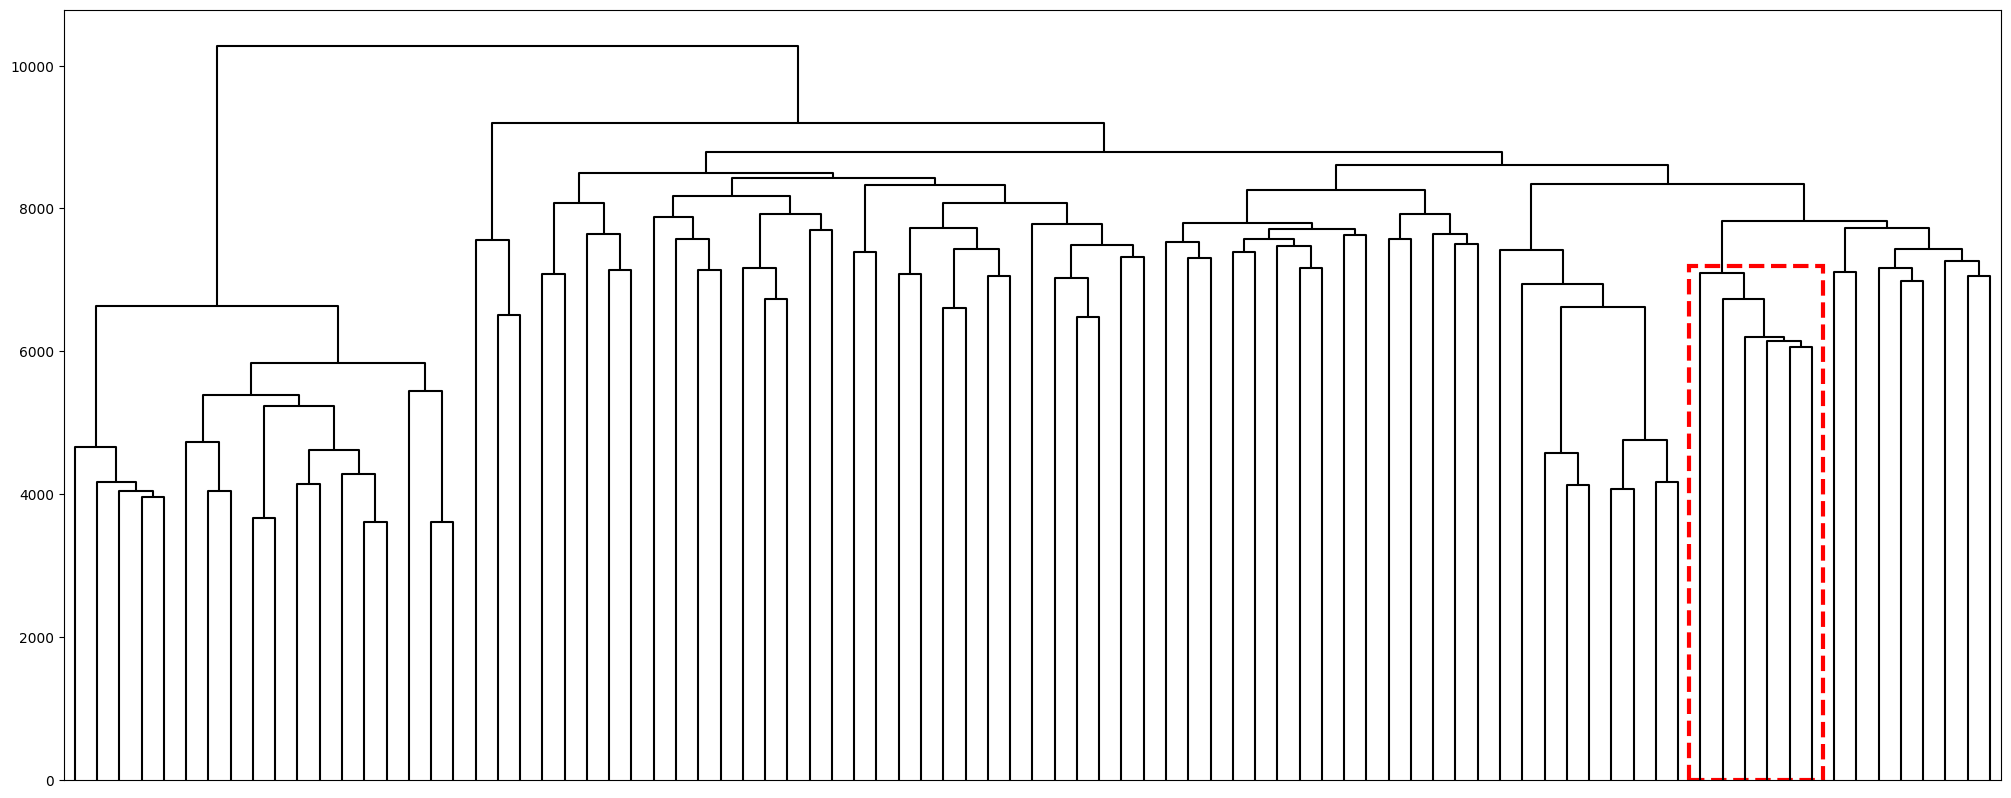

In [143]:
# illustrate linkaga with a dendrogram, red box highlights the debris-flow cluster
fig, ax = plt.subplots(figsize=(25, 10))

ddata = dendrogram(
    Z, no_labels=True, color_threshold=0, link_color_func=lambda k: "black", ax=ax
)

leaves = ddata["leaves"]
xpos = {leaf: 5 + 10 * i for i, leaf in enumerate(leaves)}

xs = [xpos[i] for i in idx]
xmin = min(xs) - 5
xmax = max(xs) + 5

root, nodes = to_tree(Z, rd=True)
idx_set = set(idx)


def leaves_under(node):
    if node.is_leaf():
        return {node.id}
    return leaves_under(node.left) | leaves_under(node.right)


for node in nodes:
    if not node.is_leaf():
        if leaves_under(node) == idx_set:
            cluster_height = node.dist
            break
cluster_height += 100

rect = Rectangle(
    (xmin, 0),
    xmax - xmin,
    cluster_height,
    fill=False,
    edgecolor="red",
    linewidth=3,
    linestyle="--",
)

ax.add_patch(rect)

plt.show()

### Semi-supervised Analysis

The semi-supervised approach is aimed at searching the IF segments for waveforrm segments similar to those contained in a catalog.
We use the IF segments generated in the if_illustation.ipynb notebook with the calibrated thresholds for illustration.

We follow the following procedure:
1. Extract high confidence segments from the catalog to use as refereneces. 
2. Usually we would check for singleton merges in a complete linkage dendrogram, but due to the small number of reference segments we skip this step here.
3. Do segment DTW between the IF segments and the reference segments.
4. Compute the mean of the computed DTW distances for each IF segment ignoring overlapping reference segments if any.

In [159]:
# extract reference segments as the high confidence events in the catalog
events = preproc_flow_annotations(pd.read_csv("../catalogs/XP/flow_catalog.csv"))
_, high_conf_events, _ = extract_split_flows(events, "ILL18", 2018, 2018)

ref_segments = []
for i in tqdm(
    range(high_conf_events.shape[0]), desc="ILL18: Limiting reference segment lengths"
):
    ref_segments.append(
        limit_segment_length(
            high_conf_events["start"][i],
            high_conf_events["stop"][i],
            stream_paths,
            if_mod,
        )
    )

# perform pairwise segment DTW between candidate reference segments
# usually small number and did not bother to save results
n = len(ref_segments)
indices = [(i, j, ref_segments) for i in range(n) for j in range(i + 1, n)]

with mp.Pool(mp.cpu_count()) as pool:
    results = list(
        tqdm(
            pool.imap(distribute_pairwise_segment_dtw, indices),
            total=len(indices),
            desc="ILL18: Performing Pairwise Segment DTW between candidate reference segments",
        )
    )

# create dataframe of reference segments with start and stop times for later use
ref_segments_df = pd.DataFrame(
    {"start": [i[2] for i in ref_segments], "stop": [i[3] for i in ref_segments]}
)

ILL18: Limiting reference segment lengths: 100%|██████████| 6/6 [00:03<00:00,  1.97it/s]
ILL18: Performing Pairwise Segment DTW between candidate reference segments: 100%|██████████| 15/15 [00:31<00:00,  2.13s/it]


In [160]:
# do segment DTW between each IF segment and the reference segments
try:
    with open("../output/illustration/ILL18_ref.pkl", "rb") as f:
        results = pickle.load(f)

except:
    paired_segments = []

    for i in tqdm(
        range(if_segments_df.shape[0]), desc="ILL18: Limiting IF segment lengths"
    ):
        paired_segments.append(
            (
                limit_segment_length(
                    if_segments_df["start"][i],
                    if_segments_df["stop"][i],
                    stream_paths,
                    if_mod,
                ),
                ref_segments,
            )
        )

    with mp.Pool(mp.cpu_count()) as pool:
        results = list(
            tqdm(
                pool.imap(distribute_reference_segment_dtw, paired_segments),
                total=len(paired_segments),
                desc="ILL18: Performing Reference Segment DTW",
            )
        )

    with open("../output/illustration/ILL18_ref.pkl", "wb") as f:
        pickle.dump(results, f)

ILL18: Performing Reference Segment DTW: 100%|██████████| 87/87 [11:00<00:00,  7.59s/it]  


In [161]:
# compute the segment DTW distances between each IF segment and each reference segment
X = np.zeros((len(results), len(results[0])))
dtw_segments_df = if_segments_df.copy()

for i in range(len(results)):
    X[i] = np.array([np.median(results[i][k][0]) for k in range(len(results[i]))])
    cummulative_intersections, _, _ = iou(
        ref_segments_df, dtw_segments_df.iloc[[i]].reset_index(drop=True)
    )
    intersection_lengths = np.append(
        cummulative_intersections[0], np.diff(cummulative_intersections)
    )
    overlap_idx = np.where(intersection_lengths > 0)[0]
    X[i, overlap_idx] = np.nan

# extract the mean segment DTW distance to reference segments for each IF segment, ignoring any reference segments that overlap with the IF segment
# reoder the IF segments by their mean segment DTW distance to reference segments
dtw_segments_df["scores"] = np.nanmean(X, axis=1)
dtw_segments_df = dtw_segments_df.iloc[
    np.argsort(dtw_segments_df["scores"])
].reset_index(drop=True)
dtw_segments_df.head()

,start,stop,most_anomalous_start,scores
0,2018-10-29T14:25:55.470000Z,2018-10-29T17:15:55.470000Z,2018-10-29T15:24:15.470000Z,6291.031936
1,2018-07-25T16:50:03.520019Z,2018-07-25T17:42:33.520019Z,2018-07-25T16:56:43.520019Z,6314.347464
2,2018-10-29T22:40:05.470000Z,2018-10-30T00:54:15.470000Z,2018-10-29T22:45:55.470000Z,6325.464659
3,2018-08-08T17:44:13.580002Z,2018-08-08T18:09:13.580002Z,2018-08-08T17:49:13.580002Z,6441.229126
4,2018-06-11T10:30:53.740003Z,2018-06-11T11:27:33.740003Z,2018-06-11T10:47:33.740003Z,6525.356765
